In [6]:
import json
import os
from typing import List

from matplotlib import pyplot as plt

MODEL_IDS_24_H: List[str] = [
    'LinearRegression2022_02_08_15_40_14_910282',
    'SimpleNeuralNet2022_02_08_12_56_24_635436',
    'SimpleNeuralNet2022_02_14_15_16_38_768994',
    'TimeSeriesTransformer2022_02_07_21_41_35_195139',
    # 'TimeSeriesTransformer2022_02_08_00_14_35_897198',
    # 'TimeSeriesTransformer2022_02_07_23_48_05_910516',
    'TimeSeriesTransformerWithConvolutionalAttention2022_02_07_21_55_14_101949',
    # 'TimeSeriesTransformerWithConvolutionalAttention2022_02_07_22_20_04_159231',
    # 'TimeSeriesTransformerWithConvolutionalAttention2022_02_07_22_42_57_369977',
    'Informer2022_02_07_21_23_12_947796'
]
LABEL_IDS_24_H: List[str] = [
    'Linear Regression',
    'Neural Net (2 Layers a 256 Neurons)',
    'Neural Net (2 Layers a 2048 Neurons)',
    'Transformer (generative)',
    # 'Transformer (1 step ahead)',
    # 'Transformer (teacher forcing)',
    'Conv. Transformer (generative)',
    # 'Conv. Transformer (1 step ahead)',
    # 'Conv. Transformer (teacher forcing)',
    'Informer (generative)'    
]


model_ids = MODEL_IDS_24_H
labels = LABEL_IDS_24_H

assert len(model_ids) == len(labels)

experiments = []
for model_id in model_ids:
    with open(os.path.join('..', 'experiments', 'final', model_id + '.json')) as file:
        experiment_data = json.load(file)
        experiments.append(experiment_data)        

Manually appending data obtaining from modified Transformer model

In [7]:
evaluation_afeka = {
    "total_mape_loss": 0.023675190284848213,
    "total_mase_loss": 0.38395175337791443,
    "mape_losses_by_prediction_variable": {
        "0": 0.016653645783662796,
        "1": 0.019282547757029533,
        "2": 0.020425185561180115,
        "3": 0.021262390539050102,
        "4": 0.02209392562508583,
        "5": 0.02290309965610504,
        "6": 0.023395316675305367,
        "7": 0.023520661517977715,
        "8": 0.023738687857985497,
        "9": 0.02407965436577797,
        "10": 0.02430720627307892,
        "11": 0.02447805553674698,
        "12": 0.024688521400094032,
        "13": 0.024786850437521935,
        "14": 0.02468729391694069,
        "15": 0.024831658229231834,
        "16": 0.02512185648083687,
        "17": 0.025234540924429893,
        "18": 0.025135591626167297,
        "19": 0.025012850761413574,
        "20": 0.024971695616841316,
        "21": 0.025272659957408905,
        "22": 0.0259146299213171,
        "23": 0.026406053453683853,
    },
    "mase_losses_by_prediction_variable": {
        "0": 0.2690238356590271,
        "1": 0.31466925144195557,
        "2": 0.33335986733436584,
        "3": 0.34786558151245117,
        "4": 0.36220869421958923,
        "5": 0.37527722120285034,
        "6": 0.38247519731521606,
        "7": 0.38383591175079346,
        "8": 0.3869197964668274,
        "9": 0.3916664719581604,
        "10": 0.39464038610458374,
        "11": 0.3976014256477356,
        "12": 0.4013098180294037,
        "13": 0.40241631865501404,
        "14": 0.4003416895866394,
        "15": 0.402098149061203,
        "16": 0.40582072734832764,
        "17": 0.40708741545677185,
        "18": 0.4055078625679016,
        "19": 0.40296003222465515,
        "20": 0.4013899862766266,
        "21": 0.40546107292175293,
        "22": 0.41523149609565735,
        "23": 0.4223049581050873,
    },
}


experiments.append(
{
    'experimentName': 'Transformer Afeka', 
    'trainingReport': None, 
    'evaluation': evaluation_afeka
})

labels.append('Transformer (Afeka)')

Compare the average losses

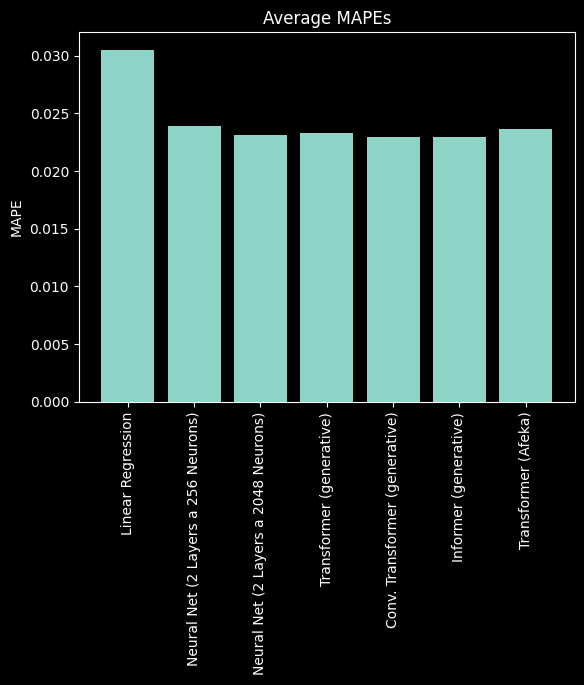

In [8]:
def create_loss_comparison_diagram(losses: List[float], title: str, bar_names: List[str], y_axis_label: str) -> None:
    """
    Creates a bar diagram which compares the losses of different models
    :param losses: the loss of each model to plot
    :param title: the name of the diagram
    :param bar_names: the name of each bar (should identify the model)
    :param y_axis_label: the name of the y axis
    """
    assert len(losses) == len(bar_names)
    plt.bar(bar_names, losses)
    plt.xticks(rotation='vertical')
    plt.ylabel(y_axis_label)
    plt.title(title)
    plt.show()


mape_losses = [experiment['evaluation']['total_mape_loss'] for experiment in experiments]
create_loss_comparison_diagram(mape_losses, 'Average MAPEs', labels, 'MAPE')

Compare the losses by prediction variable:

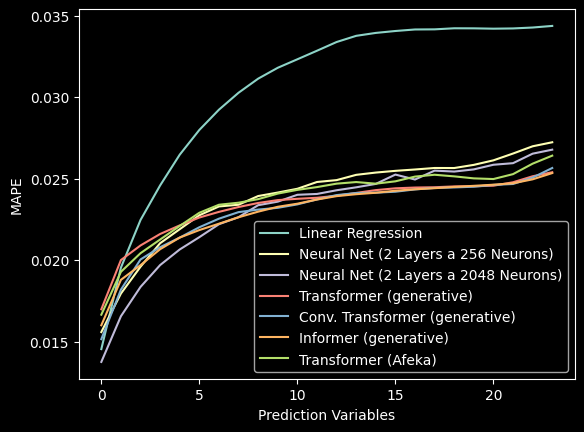

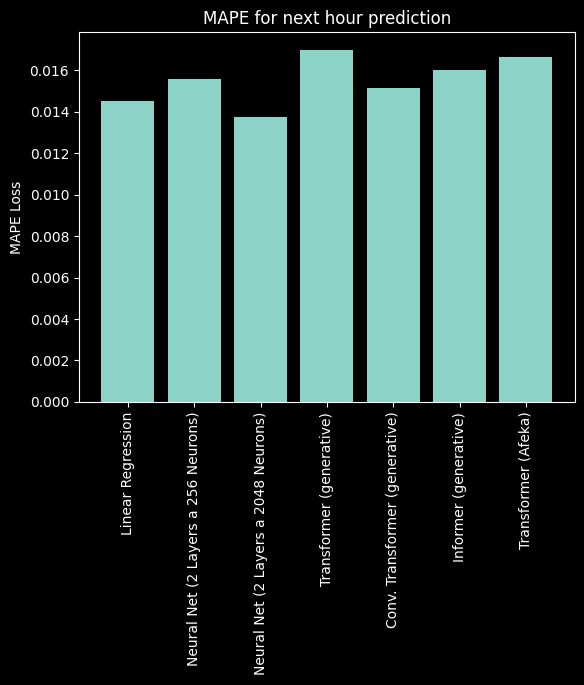

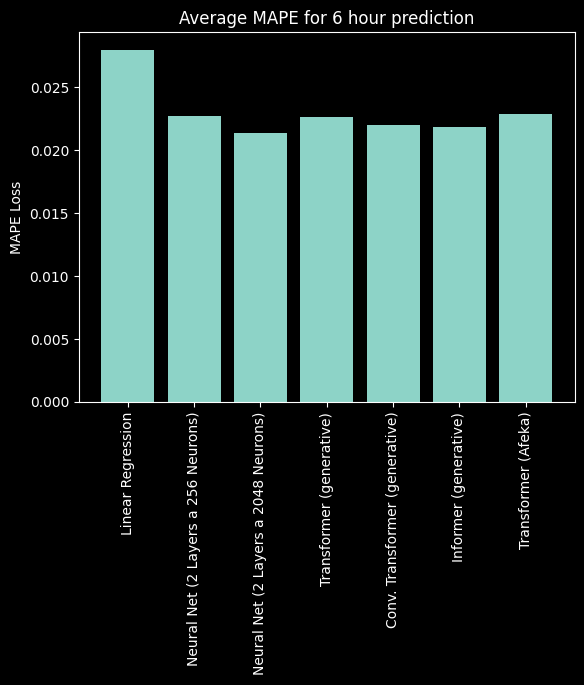

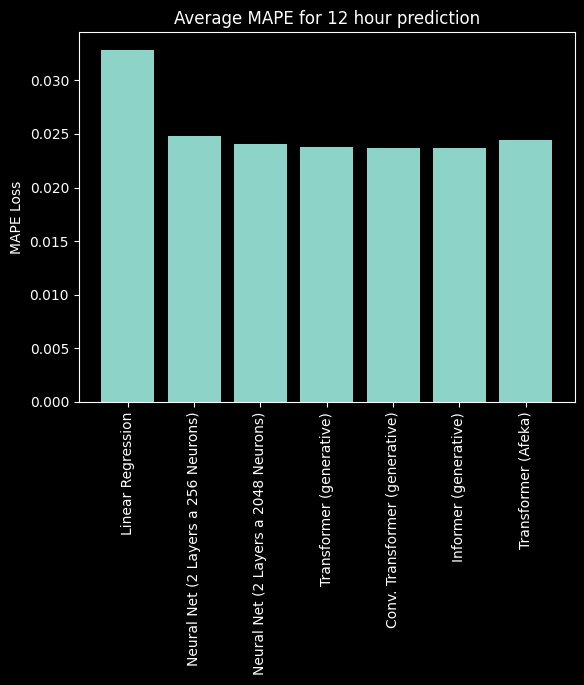

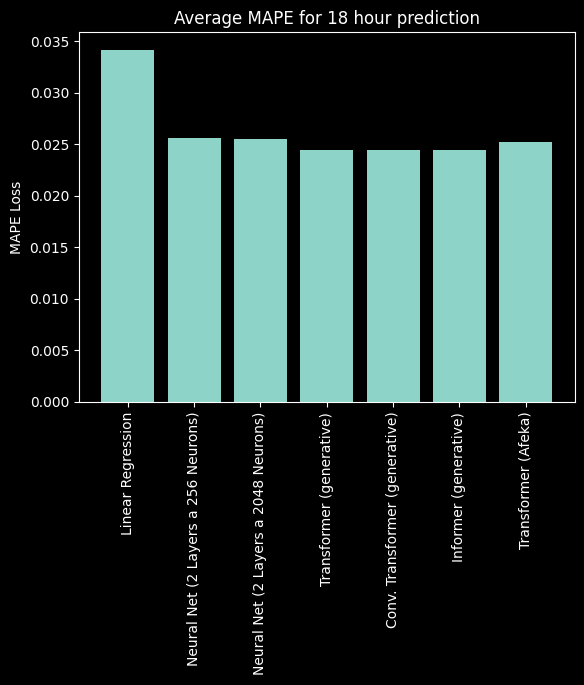

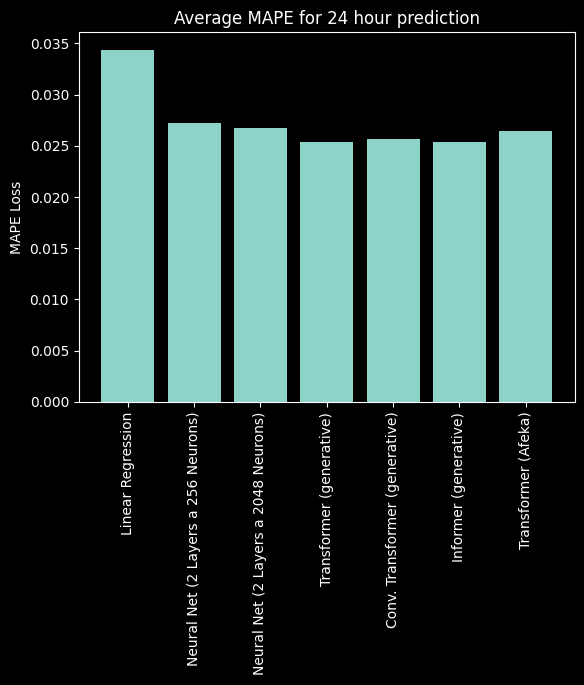

In [9]:
# Compare over all variables
fig = plt.figure()
next_hour_mape_losses = []
mape_losses_6_hours = []
mape_losses_12_hours = []
mape_losses_18_hours = []
mape_losses_24_hours = []
for index, experiment in enumerate(experiments):
    mape_losses_by_predicted_variable = []
    for variable in experiment['evaluation']['mape_losses_by_prediction_variable']:
        mape_loss = experiment['evaluation']['mape_losses_by_prediction_variable'][variable]
        mape_losses_by_predicted_variable.append(mape_loss)
        if variable == '0':
            next_hour_mape_losses.append(mape_loss)
        elif variable == '5':
            mape_losses_6_hours.append(mape_loss)
        elif variable == '11':
            mape_losses_12_hours.append(mape_loss)
        elif variable == '17':
            mape_losses_18_hours.append(mape_loss)
        elif variable == '23':
            mape_losses_24_hours.append(mape_loss)
    plt.plot(mape_losses_by_predicted_variable, label=labels[index])
plt.xlabel('Prediction Variables')
plt.ylabel('MAPE')
plt.legend(loc='lower right')
plt.show()

# Compare over single variables
create_loss_comparison_diagram(next_hour_mape_losses, 'MAPE for next hour prediction', labels, 'MAPE Loss')
create_loss_comparison_diagram(mape_losses_6_hours, 'Average MAPE for 6 hour prediction', labels, 'MAPE Loss')
create_loss_comparison_diagram(mape_losses_12_hours, 'Average MAPE for 12 hour prediction', labels, 'MAPE Loss')
create_loss_comparison_diagram(mape_losses_18_hours, 'Average MAPE for 18 hour prediction', labels, 'MAPE Loss')
create_loss_comparison_diagram(mape_losses_24_hours, 'Average MAPE for 24 hour prediction', labels, 'MAPE Loss')


Show the training processes:

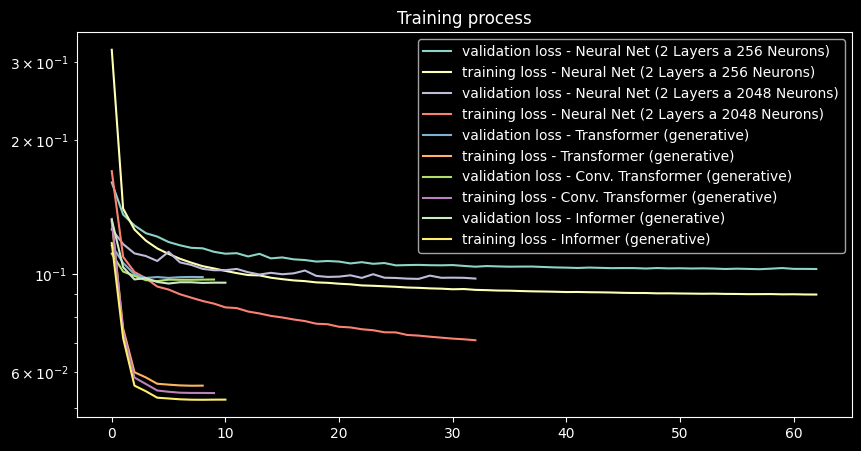

In [10]:
fig = plt.figure(figsize=(10, 5))
for index, experiment in enumerate(experiments):
    if 'trainingReport' in experiment and experiment['trainingReport']:
        epochs = experiment['trainingReport']['epochs']
        validation_losses = [epoch['validationLoss'] for epoch in epochs]
        training_losses = [epoch['trainingLoss'] for epoch in epochs]
        name = labels[index]
        plt.plot(validation_losses, label='validation loss - ' + name)
        plt.plot(training_losses, label='training loss - ' + name)
        plt.legend(loc='upper right')
        plt.yscale('log')
        plt.title('Training process')
plt.show()